# 03 — Training  ⏱️ SLOW — run this the night before the demo

This is the step that takes real time (many minutes to hours depending on
subset size / epochs / GPU). **Run it ahead of time** and let it save
checkpoints to `../checkpoints/`. During the live demo you don't re-run this
notebook — you just load the checkpoint it produced in `04_decomposition`.

Crash-recovery: training resumes automatically from `yolov3_last.pt` +
its JSON sidecar if this notebook (or the machine) is interrupted, so a
long run is safe to leave going overnight.

In [1]:
import sys, os, json
sys.path.append(os.path.abspath("../src"))
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from model import YOLOv3
from dataset import CocoSubsetDataset, yolo_collate_fn
from train_utils import fit

with open("../checkpoints/run_config.json") as f:
    cfg = json.load(f)
CLASS_NAMES, IMG_SIZE, DATA_ROOT, BATCH_SIZE = cfg["class_names"], cfg["img_size"], cfg["data_root"], cfg["batch_size"]
NUM_CLASSES = len(CLASS_NAMES)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


## Training config — the knobs you'd actually tune before the demo run

In [2]:
EPOCHS = 300
LEARNING_RATE = 1e-4
CKPT_DIR = "../checkpoints"

train_ds = CocoSubsetDataset(DATA_ROOT, "train2017", CLASS_NAMES, img_size=IMG_SIZE,
                              images_per_class=150, augment=True)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           collate_fn=yolo_collate_fn, num_workers=0)

model = YOLOv3(num_classes=NUM_CLASSES).to(DEVICE)

loading annotations into memory...
Done (t=10.53s)
creating index...
index created!


In [3]:
history = fit(model, train_loader, DEVICE, epochs=EPOCHS, lr=LEARNING_RATE,
              ckpt_dir=CKPT_DIR, num_classes=NUM_CLASSES, resume=True)

/tf/shared_data/yolo_tucker/src/train_utils.py:74: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location=device)


Resumed from epoch 300 (best_loss=2.4316)


## Loss curve — sanity check that training actually converged before the demo

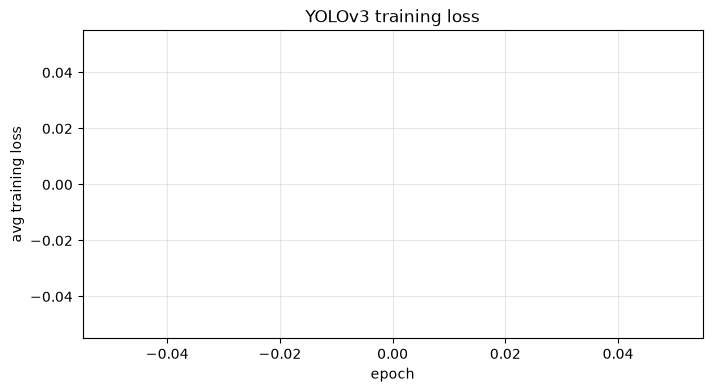

IndexError: list index out of range

In [4]:
losses = [h["loss"] for h in history]
plt.figure(figsize=(8, 4))
plt.plot(losses, marker="o")
plt.xlabel("epoch"); plt.ylabel("avg training loss"); plt.title("YOLOv3 training loss")
plt.grid(alpha=0.3)
plt.show()
print(f"final loss: {losses[-1]:.4f}  (best: {min(losses):.4f})")

## Output

`../checkpoints/yolov3_best.pt` — the trained weights the decomposition
notebook loads. `../checkpoints/history.json` — full loss history if you
want to show the convergence plot live without re-running training.